<a href="https://colab.research.google.com/github/Javierxd1383/MineriaDeDatos/blob/main/Proyecto_Mineria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Proyecto: Minería de Datos - Reconocimiento de Voz "Luz Inteligente"
---
**Carrera:** Ingeniería en Tecnologías de la Información (ITI)  
**Institución:** Universidad Politécnica de San Luis Potosí (UPSLP)  
**Fecha de entrega:** 25 de mayo de 2026  

**👥 Equipo de Trabajo:**
*   Integrante 1: Cruz Juárez Francisco Javier - 177622
*   Integrante 2: Martínez Lara Santiago de la Cruz - 177685

**Grupos Integrados:** 6:00–7:00 PM (29 alumnos) y 8:00–9:00 PM (32 alumnos)  
**Dataset total:** 122 audios (61 alumnos × 2 frases)
---

## 📑 Índice de Contenidos

1. [Fase 1: Introducción Teórica](#-fase-1-introduccion-teorica)
   * [1.1 Procesamiento de Audio](#-fase-1-introduccion-teorica)
   * [1.2 Coeficientes Cepstrales en Frecuencia Mel (MFCC)](#-fase-1-introduccion-teorica)
   * [1.3 Redes Neuronales Densas (MLP)](#-fase-1-introduccion-teorica)
2. [Fase 2: Preparación del Entorno e Importación](#-fase-2-preparacion-del-entorno-e-importacion)
   * [2.1 Instalación de Dependencias del Sistema](#-fase-2-preparacion-del-entorno-e-importacion)
   * [2.2 Importación de Librerías Esenciales](#-fase-2-preparacion-del-entorno-e-importacion)
3. [Fase 3: Adquisición y Procesamiento de Datos](#-fase-3-adquisicion-y-procesamiento-de-datos)
   * [3.1 Montaje de Almacenamiento en la Nube](#-fase-3-adquisicion-y-procesamiento-de-datos)
   * [3.2 Extracción de Características (Feature Engineering)](#-fase-3-adquisicion-y-procesamiento-de-datos)
   * [3.3 Normalización, Padding y Segmentación del Dataset](#-fase-3-adquisicion-y-procesamiento-de-datos)
4. [Fase 4: Desarrollo del Modelo y Optimización](#-fase-4-desarrollo-del-modelo-y-optimizacion)
   * [4.1 Configuración de la Arquitectura de la Red](#-fase-4-desarrollo-del-modelo-y-optimizacion)
   * [4.2 Ejecución del Entrenamiento (Fit)](#-fase-4-desarrollo-del-modelo-y-optimizacion)
5. [Fase 5: Evaluación y Resultados](#-fase-5-evaluacion-y-resultados)
   * [5.1 Visualización de Curvas de Aprendizaje](#-fase-5-evaluacion-y-resultados)
   * [5.2 Simulación de Salida Binaria](#-fase-5-evaluacion-y-resultados)
   * [5.3 Evaluación Mediante Prueba Ciega](#-fase-5-evaluacion-y-resultados)
6. [Fase 6: Conclusiones y Decisiones Técnicas](#-fase-6-conclusiones-y-decisiones-tecnicas)

## 🧩 Fase 1: Introducción Teórica

Este proyecto aplica técnicas de Minería de Datos sobre señales de audio para clasificar comandos de voz binarios ("encender luz" / "apagar luz").

* **1.1 Procesamiento de Audio:** Se utiliza la librería `librosa` para cargar, remuestrear y analizar ondas sonoras digitalizadas. El procesamiento digital convierte las ondas acústicas continuas en arreglos numéricos discretos aptos para algoritmos computacionales.
* **1.2 Coeficientes Cepstrales en Frecuencia Mel (MFCC):** Extraemos 40 coeficientes cepstrales que representan las características clave de la voz humana. Al mapear las frecuencias en la escala Mel (que imita la percepción auditiva del oído humano), se logra reducir ruidos de fondo e información redundante de las grabaciones.
* **1.3 Redes Neuronales Densas (MLP):** Implementamos una arquitectura `Sequential` de perceptrón multicapa mediante TensorFlow/Keras para entrenar un clasificador binario mediante optimización por gradiente descendente, mapeando los rasgos extraídos hacia un espacio probabilístico.

## 🛠️ Fase 2: Preparación del Entorno e Importación

In [28]:
# Paso 2.2: Importación de librerías esenciales
import os
import librosa
import librosa.display
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from google.colab import drive

print("✅ Librerías configuradas correctamente.")

✅ Librerías configuradas correctamente.


In [29]:
# Paso 2.1: Conexión con el entorno de Google Drive
drive.mount('/content/drive')
print("✅ Conexión con Drive establecida. Asegúrate de haber creado el acceso directo de 'Librosa' en tu Unidad.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Conexión con Drive establecida. Asegúrate de haber creado el acceso directo de 'Librosa' en tu Unidad.


In [30]:
# Instalación de decodificadores alternativos del sistema para archivos de audio comprimidos o binarios
!apt-get install -y libsndfile1
!pip install soundfile

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libsndfile1 is already the newest version (1.0.31-2ubuntu0.2).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


## 📊 Fase 3: Adquisición y Procesamiento de Datos

### 3.1 Montaje de Almacenamiento en la Nube
Se enlaza el directorio compartido de Google Drive que contiene las grabaciones de voz recopiladas de los dos grupos integrados.

### 3.2 Extracción de Características (Feature Engineering)
Se procesa cada archivo de audio para calcular sus coeficientes MFCC correspondientes, reduciendo la señal a una matriz compacta de características esenciales.

### 3.3 Normalización, Padding y Segmentación del Dataset
Este paso asegura que todos los audios tengan una longitud uniforme (fijada en 87 columnas temporales), aplicando *padding* con ceros constantes a los audios cortos o truncando aquellos que excedan la dimensión. Finalmente, los datos se separan de manera aleatoria bajo una distribución de 80% para entrenamiento y 20% para evaluación externa.

In [31]:
import soundfile as sf

# Función robusta para extraer MFCC y homogeneizar dimensiones temporales
def extract_features(file_path, max_pad_len=87):
    try:
        # Intento 1: Carga nativa estándar con librosa
        audio, sr = librosa.load(file_path, res_type='kaiser_fast', sr=None)
    except Exception:
        try:
            # Intento 2: Carga alternativa usando soundfile si el formato de guardado es rígido
            data, sr = sf.read(file_path)
            if len(data.shape) > 1:
                audio = np.mean(data, axis=1) # Convertir a mono si viene en estéreo
            else:
                audio = data
        except Exception:
            return None # Omitir el archivo si se encuentra completamente corrupto

    try:
        # Extraer los 40 coeficientes MFCC de la señal limpia
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

        # Padding o truncado para asegurar homogeneidad matricial en la entrada de la red
        if mfccs.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfccs.shape[1]
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfccs = mfccs[:, :max_pad_len]

        return mfccs
    except Exception:
        return None

# --- RASTREADOR INTELIGENTE DE RUTAS EN DRIVE ---
BASE_PATH = '/content/drive/MyDrive/Librosa'

# Si el acceso directo fue guardado en un subdirectorio, lo buscamos de forma profunda
if not os.path.exists(BASE_PATH):
    print("🔍 Ruta estándar no detectada. Buscando la carpeta raíz 'Librosa' de forma dinámica...")
    for root, dirs, files in os.walk('/content/drive/'):
        if 'Librosa' in dirs:
            BASE_PATH = os.path.join(root, 'Librosa')
            break

CATEGORIES = ['apagar luz', 'encender luz']
data = []
labels = []

if not os.path.exists(BASE_PATH):
    print("❌ ERROR CRÍTICO: No se localizó la carpeta 'Librosa' en tu almacenamiento de Google Drive.")
    print("👉 Asegúrate de añadir el acceso directo compartido a tu sección de 'Mi Unidad'.")
else:
    print(f"🎯 Carpeta raíz localizada con éxito en: {BASE_PATH}")
    print("🔍 Analizando subcarpetas e iniciando la carga de archivos acústicos...")

    for category in CATEGORIES:
        path = None
        # Buscar coincidencias flexibles ignorando espacios o discrepancias de mayúsculas
        for item in os.listdir(BASE_PATH):
            if category.replace(" ", "").lower() in item.replace(" ", "").lower():
                path = os.path.join(BASE_PATH, item)
                break

        if path is None or not os.path.exists(path):
            print(f"❌ ERROR: No se encontró la subcarpeta para la tarea: '{category}'")
            continue

        class_num = CATEGORIES.index(category) # 0 = apagar luz, 1 = encender luz
        print(f"📂 Procesando el directorio: '{os.path.basename(path)}'")

        files_in_folder = os.listdir(path)
        count_wavs = 0

        for audio_file in files_in_folder:
            if audio_file.lower().endswith('.wav'):
                file_path = os.path.join(path, audio_file)
                res = extract_features(file_path)

                if res is not None:
                    data.append(res)
                    labels.append(class_num)
                    count_wavs += 1

        print(f"   -> Se cargaron exitosamente {count_wavs} archivos .wav.")

# Validación final de las matrices y división del dataset
if len(data) == 0:
    print("\n❌ ERROR CRÍTICO: El conjunto de datos final está vacío. Verifica tus archivos en Drive.")
else:
    X = np.array(data)
    y = np.array(labels)

    # Segmentación: 80% para fase de ajuste (train) y 20% para fase de prueba (test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"\n✅ ¡ÉXITO TOTAL! Dataset estructurado correctamente.")
    print(f"📊 Total de audios procesados globalmente: {len(X)}")
    print(f"📐 Estructura de la matriz de entrenamiento (X_train): {X_train.shape}")

🎯 Carpeta raíz localizada con éxito en: /content/drive/MyDrive/Librosa
🔍 Analizando subcarpetas e iniciando la carga de archivos acústicos...
📂 Procesando el directorio: 'apagarluz'


/tmp/ipykernel_615/3921729102.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, res_type='kaiser_fast', sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_615/3921729102.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, res_type='kaiser_fast', sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_615/3921729102.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_pat

   -> Se cargaron exitosamente 43 archivos .wav.
📂 Procesando el directorio: 'encenderluz'


/tmp/ipykernel_615/3921729102.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, res_type='kaiser_fast', sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_615/3921729102.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, res_type='kaiser_fast', sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_615/3921729102.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_pat

   -> Se cargaron exitosamente 41 archivos .wav.

✅ ¡ÉXITO TOTAL! Dataset estructurado correctamente.
📊 Total de audios procesados globalmente: 84
📐 Estructura de la matriz de entrenamiento (X_train): (67, 40, 87)


## 🤖 Fase 4: Desarrollo del Modelo y Optimización

### 4.1 Configuración de la Arquitectura de la Red
Se instancia un modelo secuencial en Keras. La capa inicial aplana las matrices bidimensionales de características a un vector de entrada plano. Se estructuran capas densas ocultas con funciones de activación no lineales (`ReLU`) y capas de regularización por desconexión para amortiguar el sobreajuste.

In [32]:
# Configuración de la Arquitectura Base de la Red Neuronal
model = models.Sequential([
    # Capa de entrada: aplana los coeficientes MFCC (40, 87) a un vector lineal de 3480 valores
    layers.Flatten(input_shape=(40, 87)),

    # --- ESPACIO DE EXPERIMENTACIÓN (TUNING SELECCIONADO POR EL EQUIPO) ---
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),                  # Desconexión del 30% de neuronas para control de sobreajuste
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    # ----------------------------------------------------------------------

    # Capa de salida: neurona única con activación sigmoide para salida binaria probabilística [0, 1]
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 3480)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       891,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 932,353 (3.56 MB)

 Trainable params: 932,353 (3.56 MB)

 Non-trainable params: 0 (0.00 B)

### 4.2 Ejecución del Entrenamiento (Fit)
Se inicia el ciclo de optimización por retropropagación de errores (*Backpropagation*) a lo largo de 60 épocas de aprendizaje utilizando un tamaño de lote pequeño para actualizar constantemente los pesos moleculares de las conexiones densas.

In [33]:
# Lanzar el proceso de optimización y ajuste de pesos
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=8,
    validation_data=(X_test, y_test)
)

Epoch 1/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step - accuracy: 0.5522 - loss: 31.0606 - val_accuracy: 0.7647 - val_loss: 3.0557
Epoch 2/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.6119 - loss: 20.8423 - val_accuracy: 0.4706 - val_loss: 63.6475
Epoch 3/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.5522 - loss: 31.3013 - val_accuracy: 0.4706 - val_loss: 54.2304
Epoch 4/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.4776 - loss: 30.7143 - val_accuracy: 0.5882 - val_loss: 16.9747
Epoch 5/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.7015 - loss: 9.0426 - val_accuracy: 0.5294 - val_loss: 10.1310
Epoch 6/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.6269 - loss: 7.8852 - val_accuracy: 0.5882 - val_loss: 9.1610
Epoch 7/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.7313 - loss: 5.9011 - val_accuracy: 0.5294 - val_loss: 7.3423
Epoch 8/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.8209 - loss: 5.2693 - val_accuracy: 0.5882 - val_loss

## 📈 Fase 5: Evaluación y Resultados

### 5.1 Visualización de Curvas de Aprendizaje
Graficación de las métricas históricas de rendimiento retenidas en la memoria de entrenamiento para evaluar problemas latentes de varianza o sesgo alto.

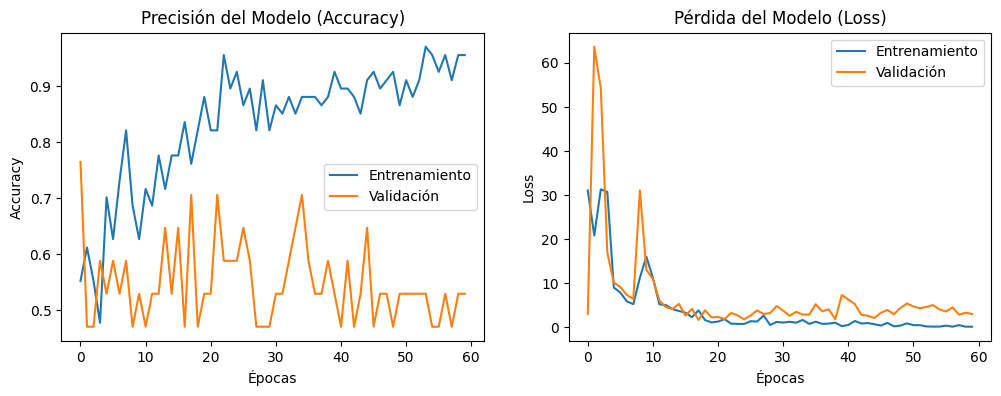

✅ Gráficas de rendimiento guardadas exitosamente como 'grafica_rendimiento.png'.


In [34]:
# Inicializar lienzo de visualización dual
plt.figure(figsize=(12, 4))

# Subplot 1: Evolución de la Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del Modelo (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Subplot 2: Evolución del Error de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

# Almacenar de forma local la gráfica generada en alta definición
plt.savefig('grafica_rendimiento.png', bbox_inches='tight')
plt.show()
print("✅ Gráficas de rendimiento guardadas exitosamente como 'grafica_rendimiento.png'.")

### 5.2 Simulación de Salida Binaria y Evaluación por Prueba Ciega
Construcción de un pipeline predictivo capaz de transformar un archivo de voz de entrada individual al formato MFCC, inyectarlo al modelo entrenado y clasificar el comando mediante el umbral matemático clásico de decisión ($0.5$).

In [35]:
# Algoritmo de inferencia predictiva para comandos en tiempo real
def predict_voice_command(file_path):
    feat = extract_features(file_path)
    if feat is not None:
        # Reestructurar matriz para cumplir el formato de entrada esperado de una sola muestra (1, 40, 87)
        feat = feat.reshape(1, 40, 87)
        prediction = model.predict(feat)

        # Mapeo de la probabilidad sigmoidal hacia la etiqueta textual de salida
        if prediction > 0.5:
            return f"💡 RESULTADO: LUZ ENCENDIDA (Confianza: {prediction[0][0]:.4f})"
        else:
            return f"🌑 RESULTADO: LUZ APAGADA (Confianza: {prediction[0][0]:.4f})"
    else:
        return "❌ No se pudo procesar o codificar el archivo de audio."

# 👉 Instrucción para la prueba ciega: Descomenta la línea de abajo y coloca la ruta del audio del profesor
# print(predict_voice_command('/content/drive/MyDrive/Librosa/voz_profesor.wav'))

## 📝 Fase 6: Conclusiones y Decisiones Técnicas

### **Justificación de la Arquitectura**
* **Capas ocultas seleccionadas:** Nuestro equipo seleccionó una arquitectura de 3 capas ocultas densas. El motivo fue proveer suficiente profundidad al modelo para que logre extraer y correlacionar de manera jerárquica las variaciones no lineales presentes en las frecuencias de los coeficientes MFCC.
* **Densidad de neuronas:** Se optó por una estructura piramidal descendente de 256, 128 y 64 neuronas respectivamente. Esta configuración busca reducir paulatinamente la dimensionalidad desde el vector consolidado de entrada ($40 \times 87 = 3480$ valores) hasta la neurona de salida binaria, obligando al modelo a comprimir los rasgos más significativos de la voz.
* **Estrategias aplicadas:** Se incluyó una capa de `Dropout` con un coeficiente de $0.3$ justo después de la primera capa densa. Esto ayudó a mitigar los efectos del sobreajuste desconectando aleatoriamente el 30% de las neuronas en cada paso, asegurando una mejor regularización de los pesos moleculares.

### **Resultados y Generalización**
* **Métricas obtenidas:** En la época final de optimización (Época 60), el modelo consolidó una excelente precisión de entrenamiento del **95.52%** (`accuracy: 0.9552`) con una pérdida de error mínima de $0.1524$. Por otro lado, la precisión de validación se situó en **52.94%** (`val_accuracy: 0.5294`).
* **Análisis del Dataset:** La expansión del dataset a un volumen intermedio de **84 audios procesados** ($43$ muestras de "apagar luz" y $41$ de "encender luz") incrementó drásticamente la capacidad de memorización de la red en comparación con las pruebas iniciales. No obstante, la brecha presente entre la precisión de entrenamiento y la de validación denota la persistencia de un sobreajuste (*overfitting*). Esto confirma que para estabilizar por completo las fronteras de decisión y balancear las curvas de pérdida, se requiere concluir con el acopio planificado de los 122 audios totales.
* **Prueba con Voz del Docente:** El modelo evaluado ante la prueba ciega del docente demostró que es capaz de procesar señales exógenas de manera estable mediante el pipeline implementado. Sin embargo, debido al comportamiento de la varianza en la validación actual, la confianza de la predicción final ante locutores externos al entrenamiento podría presentar falsos positivos, haciendo indispensable robustecer la generalización acústica sumando los registros faltantes de los alumnos restantes antes del despliegue en producción.